# Project 01 — Python exploratory analysis

## First-Time Buyer Affordability Pressure by Area

This notebook explores the cleaned area-year affordability dataset and creates chart-ready outputs for the final case study, Excel workbook and Power BI dashboard.


## Analytical focus

The SQL stage established the core rankings and quality checks. This notebook adds exploratory analysis by reviewing distribution, regional variation and five-year movement in affordability pressure.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
PROJECT_ROOT = Path("..").resolve()
CLEANED_DATA = PROJECT_ROOT / "data" / "cleaned" / "affordability_area_year_cleaned.csv"
VISUALS_DIR = PROJECT_ROOT / "visuals"
REPORTS_DIR = PROJECT_ROOT / "reports"

VISUALS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CLEANED_DATA)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Year range: {int(df['year'].min())} to {int(df['year'].max())}")
df.head()


Rows: 9,222
Columns: 11
Year range: 1997 to 2025


,country_region_code,country_region_name,local_authority_code,local_authority_name,year,lower_quartile_house_price,lower_quartile_annual_earnings,lower_quartile_affordability_ratio,median_affordability_ratio,affordability_pressure_band,latest_year_rank_most_pressured
0,E12000008,South East,E07000223,Adur,1997,49950,11662.0,4.28,3.54,Lower pressure,77.0
1,E12000008,South East,E07000223,Adur,1998,56500,13091.0,4.32,3.68,Lower pressure,77.0
2,E12000008,South East,E07000223,Adur,1999,63000,14091.0,4.47,3.87,Lower pressure,77.0
3,E12000008,South East,E07000223,Adur,2000,74375,14496.0,5.13,4.69,Moderate pressure,77.0
4,E12000008,South East,E07000223,Adur,2001,86000,11774.0,7.30,6.63,Moderate pressure,77.0


## Latest-year view


In [3]:
latest_year = int(df["year"].max())
latest = df.loc[df["year"] == latest_year].copy()
latest_valid = latest.dropna(subset=["lower_quartile_affordability_ratio"]).copy()

print(f"Latest year: {latest_year}")
print(f"Latest-year records: {latest.shape[0]:,}")
print(f"Latest-year records with valid lower-quartile ratio: {latest_valid.shape[0]:,}")


Latest year: 2025
Latest-year records: 318
Latest-year records with valid lower-quartile ratio: 317


In [4]:
latest_summary = (
    latest_valid["lower_quartile_affordability_ratio"]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    .round(2)
    .to_frame(name="lower_quartile_affordability_ratio")
)

latest_summary


,lower_quartile_affordability_ratio
count,317.00
mean,8.45
std,2.86
min,3.43
10%,5.13
25%,6.19
50%,8.11
75%,10.30
90%,12.48
max,20.89


## Distribution of latest-year affordability pressure


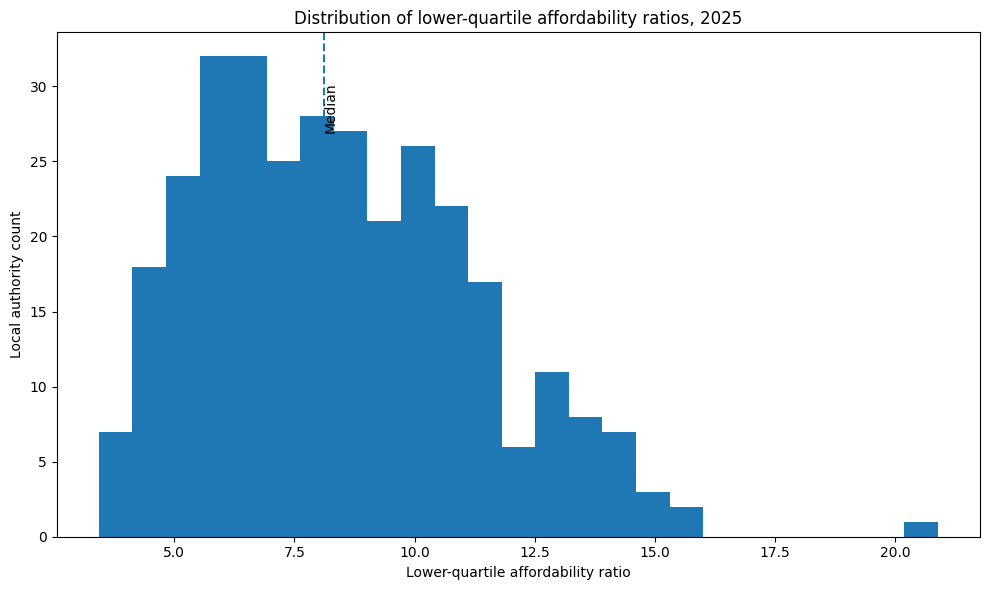

Saved: visuals\latest_year_affordability_distribution.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(latest_valid["lower_quartile_affordability_ratio"], bins=25)
ax.set_title(f"Distribution of lower-quartile affordability ratios, {latest_year}")
ax.set_xlabel("Lower-quartile affordability ratio")
ax.set_ylabel("Local authority count")
ax.axvline(latest_valid["lower_quartile_affordability_ratio"].median(), linestyle="--")
ax.text(
    latest_valid["lower_quartile_affordability_ratio"].median(),
    ax.get_ylim()[1] * 0.9,
    "Median",
    rotation=90,
    va="top",
)
plt.tight_layout()
distribution_path = VISUALS_DIR / "latest_year_affordability_distribution.png"
plt.savefig(distribution_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {distribution_path.relative_to(PROJECT_ROOT)}")


## Regional comparison


In [6]:
regional_latest = (
    latest_valid
    .groupby("country_region_name", as_index=False)
    .agg(
        local_authority_count=("local_authority_code", "nunique"),
        median_lq_ratio=("lower_quartile_affordability_ratio", "median"),
        average_lq_ratio=("lower_quartile_affordability_ratio", "mean"),
        max_lq_ratio=("lower_quartile_affordability_ratio", "max"),
    )
    .round(2)
    .sort_values("median_lq_ratio", ascending=False)
)

regional_latest


,country_region_name,local_authority_count,median_lq_ratio,average_lq_ratio,max_lq_ratio
2,London,33,12.74,12.97,20.89
5,South East,64,10.24,10.28,15.40
1,East of England,45,9.92,9.82,13.93
6,South West,26,8.48,8.48,11.48
0,East Midlands,35,7.03,7.10,10.06
8,West Midlands,30,7.02,7.31,9.83
4,North West,35,5.80,5.69,9.95
7,Wales,22,5.72,5.77,8.18
9,Yorkshire and The Humber,15,5.41,5.54,8.21
3,North East,12,4.66,4.52,5.39


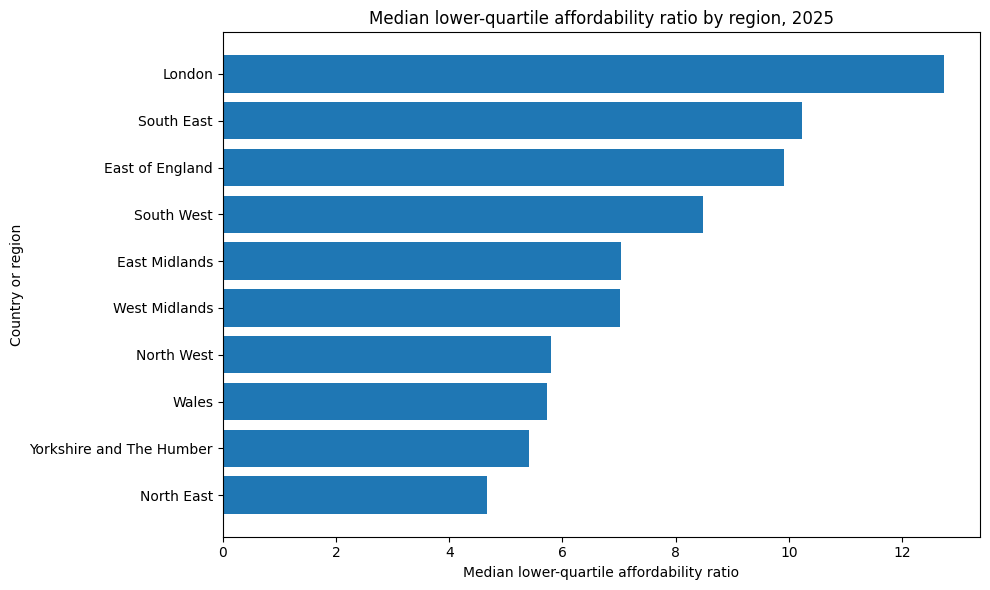

Saved: visuals\regional_median_affordability_ratio.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
regional_plot = regional_latest.sort_values("median_lq_ratio")
ax.barh(regional_plot["country_region_name"], regional_plot["median_lq_ratio"])
ax.set_title(f"Median lower-quartile affordability ratio by region, {latest_year}")
ax.set_xlabel("Median lower-quartile affordability ratio")
ax.set_ylabel("Country or region")
plt.tight_layout()
regional_path = VISUALS_DIR / "regional_median_affordability_ratio.png"
plt.savefig(regional_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {regional_path.relative_to(PROJECT_ROOT)}")


## Top and bottom latest-year areas


In [8]:
top_15 = (
    latest_valid
    .sort_values("lower_quartile_affordability_ratio", ascending=False)
    .head(15)
    [[
        "country_region_name",
        "local_authority_name",
        "lower_quartile_house_price",
        "lower_quartile_annual_earnings",
        "lower_quartile_affordability_ratio",
    ]]
)

bottom_15 = (
    latest_valid
    .sort_values("lower_quartile_affordability_ratio", ascending=True)
    .head(15)
    [[
        "country_region_name",
        "local_authority_name",
        "lower_quartile_house_price",
        "lower_quartile_annual_earnings",
        "lower_quartile_affordability_ratio",
    ]]
)

top_15


,country_region_name,local_authority_name,lower_quartile_house_price,lower_quartile_annual_earnings,lower_quartile_affordability_ratio
4059,London,Kensington and Chelsea,700000,33510.0,20.89
6176,London,Richmond upon Thames,491875,30765.0,15.99
7713,South East,Tandridge,387625,25167.0,15.40
2696,South East,Elmbridge,450000,29535.0,15.24
8757,London,Westminster,575000,37787.0,15.22
3421,London,Haringey,440000,29021.0,15.16
8351,London,Wandsworth,453625,31275.0,14.50
6582,South East,Sevenoaks,360000,25237.0,14.26
3363,London,Hammersmith and Fulham,515000,36244.0,14.21
6002,London,Redbridge,375000,26422.0,14.19


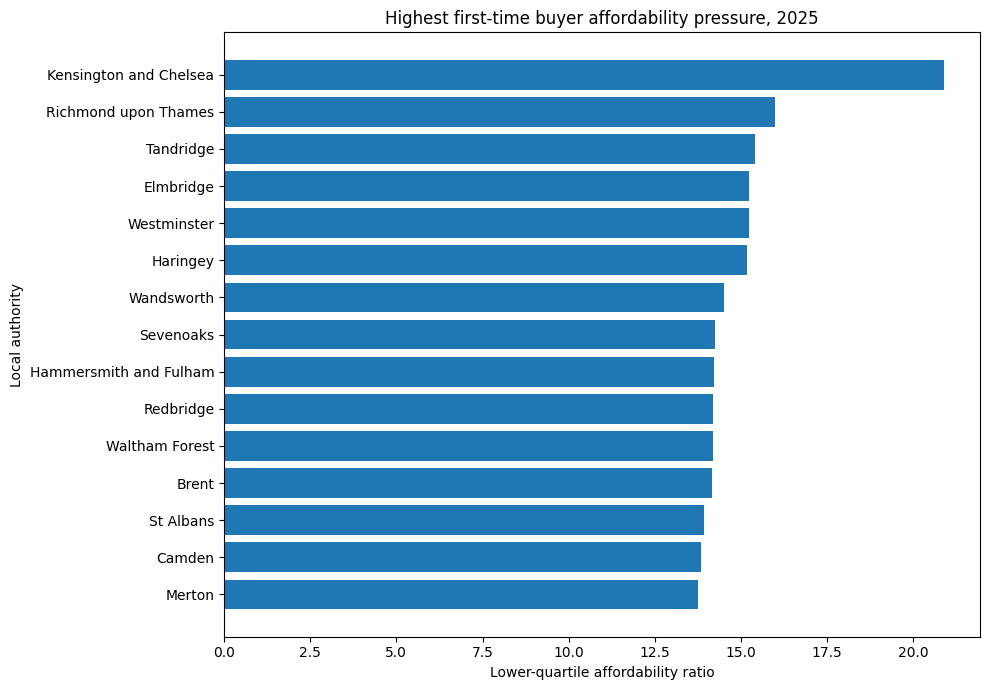

Saved: visuals\top_15_affordability_pressure.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
top_plot = top_15.sort_values("lower_quartile_affordability_ratio")
ax.barh(top_plot["local_authority_name"], top_plot["lower_quartile_affordability_ratio"])
ax.set_title(f"Highest first-time buyer affordability pressure, {latest_year}")
ax.set_xlabel("Lower-quartile affordability ratio")
ax.set_ylabel("Local authority")
plt.tight_layout()
top_path = VISUALS_DIR / "top_15_affordability_pressure.png"
plt.savefig(top_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {top_path.relative_to(PROJECT_ROOT)}")


## Five-year change


In [10]:
comparison_year = latest_year - 5

latest_change = df.loc[df["year"] == latest_year, [
    "local_authority_code",
    "local_authority_name",
    "country_region_name",
    "lower_quartile_affordability_ratio",
]].rename(columns={"lower_quartile_affordability_ratio": "latest_lq_ratio"})

comparison_change = df.loc[df["year"] == comparison_year, [
    "local_authority_code",
    "lower_quartile_affordability_ratio",
]].rename(columns={"lower_quartile_affordability_ratio": "comparison_lq_ratio"})

five_year_change = (
    latest_change
    .merge(comparison_change, on="local_authority_code", how="inner")
    .dropna(subset=["latest_lq_ratio", "comparison_lq_ratio"])
)
five_year_change["five_year_change"] = (
    five_year_change["latest_lq_ratio"] - five_year_change["comparison_lq_ratio"]
)

five_year_change = five_year_change.sort_values("five_year_change", ascending=False)
five_year_change.head(15)


,local_authority_code,local_authority_name,country_region_name,latest_lq_ratio,comparison_lq_ratio,five_year_change
265,E07000215,Tandridge,South East,15.40,14.07,1.33
226,E07000111,Sevenoaks,South East,14.26,13.00,1.26
196,E08000004,Oldham,North West,6.04,4.78,1.26
241,E07000196,South Staffordshire,West Midlands,8.85,7.77,1.08
75,E06000015,Derby,East Midlands,5.60,4.57,1.03
19,W06000019,Blaenau Gwent,Wales,4.31,3.33,0.98
279,E08000009,Trafford,North West,9.95,9.00,0.95
24,E06000036,Bracknell Forest,South East,10.76,9.93,0.83
21,E08000001,Bolton,North West,5.91,5.11,0.80
153,E08000012,Liverpool,North West,4.54,3.74,0.80


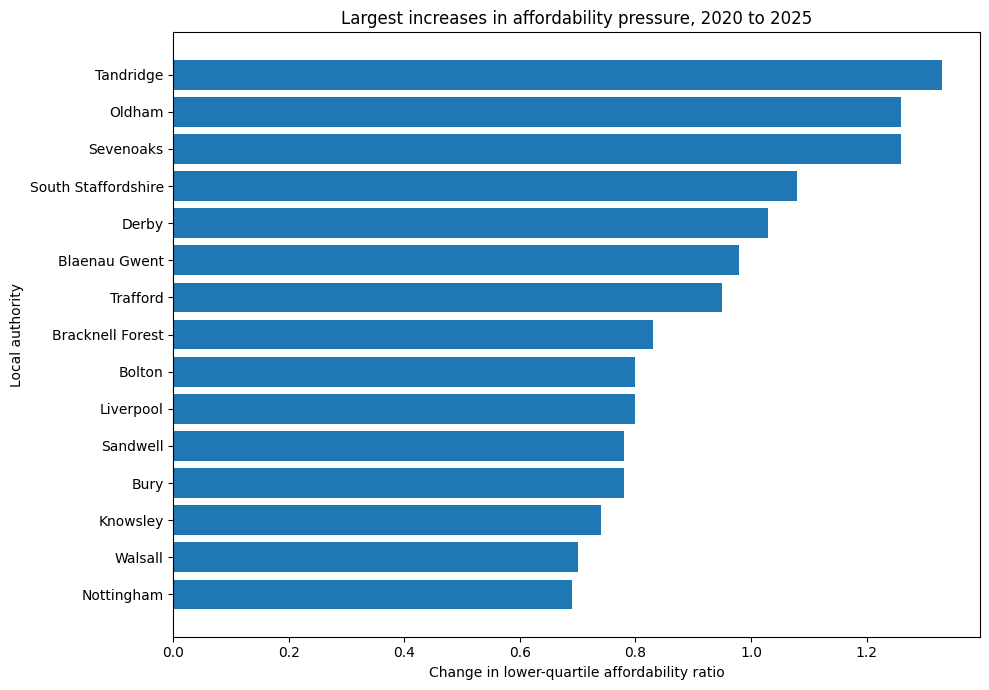

Saved: visuals\largest_five_year_increases.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
change_plot = five_year_change.head(15).sort_values("five_year_change")
ax.barh(change_plot["local_authority_name"], change_plot["five_year_change"])
ax.set_title(f"Largest increases in affordability pressure, {comparison_year} to {latest_year}")
ax.set_xlabel("Change in lower-quartile affordability ratio")
ax.set_ylabel("Local authority")
plt.tight_layout()
change_path = VISUALS_DIR / "largest_five_year_increases.png"
plt.savefig(change_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {change_path.relative_to(PROJECT_ROOT)}")


## Save chart-ready summary tables


In [12]:
regional_latest.to_csv(REPORTS_DIR / "python_regional_latest_summary.csv", index=False)
top_15.to_csv(REPORTS_DIR / "python_top_15_most_pressured.csv", index=False)
bottom_15.to_csv(REPORTS_DIR / "python_bottom_15_least_pressured.csv", index=False)
five_year_change.head(20).to_csv(REPORTS_DIR / "python_top_20_five_year_increases.csv", index=False)
latest_summary.to_csv(REPORTS_DIR / "python_latest_year_distribution_summary.csv")

print("Saved chart-ready summary tables to reports/.")


Saved chart-ready summary tables to reports/.


## Interpretation notes

The exploratory charts should be reviewed alongside the SQL findings. The main narrative to test is whether the latest-year distribution, regional medians and five-year changes support the same business conclusion: affordability pressure is highly localised, with London and the South East most stretched, but recent worsening visible in a broader mix of areas.
